# Hawkes Iでの逐次ベイズ推定
## モデル
$$
\lambda_d = \alpha \lambda_{d-1} + \beta + \gamma u_d
$$

$$
\alpha = \exp{\left(-\frac{1}{\tau}\right)}\ , \ \beta = \mu(1- \alpha)
$$

- $\alpha$:前日の状態をどのくらい引き継ぐか
- $\beta$:ベースの発生しやすさ
- $\gamma$:イベントが起きた時にどれだけ自己励起するか

## 推定
予測
$$
u_d \sim \text{Be}(\lambda^-_d)
$$

$$
\lambda^-_d = \mu + \sum_{d_i < d}u_{d_i} \gamma \exp{(- (d_i - d) / \tau)} = \alpha \lambda^-_{d-1} + \beta + \gamma \alpha u_{d-1}
$$

$$
\text{更新後強度} = \lambda^+_d = \lambda^-_d + \gamma u_d
$$

$$
\lambda^-_d = \alpha \lambda^+_{d-1} + \beta
$$

In [24]:
import sys
from pathlib import Path
# projectルートを追加
sys.path.append(str(Path().resolve().parent))

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

print("numpy:",np.__version__)
print("pandas:",pd.__version__)
print("matplotlib:",matplotlib.__version__)

spike_long = pd.read_csv(
    "../data/processed/spike_long.csv",
    parse_dates=["date"]
)

u_tokyo = pd.read_csv(
    "../data/processed/u_dict/u_Tokyo.csv",
    index_col=0,
    parse_dates=True
)

x_tokyo = pd.read_csv(
    "../data/processed/x_dict/x_Tokyo.csv",
    index_col=0,
    parse_dates=True
)


numpy: 2.4.2
pandas: 3.0.1
matplotlib: 3.10.8


In [25]:
import numpy as np
import pandas as pd


# ==========================================
# ユーティリティ
# ==========================================
def systematic_resample(weights, rng):
    """
    systematic resampling
    """
    n = len(weights)
    positions = (rng.random() + np.arange(n)) / n
    cumsum = np.cumsum(weights)
    indexes = np.zeros(n, dtype=int)

    i, j = 0, 0
    while i < n:
        if positions[i] < cumsum[j]:
            indexes[i] = j
            i += 1
        else:
            j += 1
    return indexes


def weighted_quantile(values, quantiles, sample_weight=None):
    """
    重み付き分位点
    quantiles: list-like in [0,1]
    """
    values = np.asarray(values, dtype=float)
    quantiles = np.asarray(quantiles, dtype=float)

    if sample_weight is None:
        sample_weight = np.ones(len(values), dtype=float)
    else:
        sample_weight = np.asarray(sample_weight, dtype=float)

    sorter = np.argsort(values)
    values = values[sorter]
    sample_weight = sample_weight[sorter]

    cdf = np.cumsum(sample_weight)
    cdf = cdf / cdf[-1]

    return np.interp(quantiles, cdf, values)


def posterior_summary_from_particles(particles_df, weight_col="weight"):
    """
    粒子近似された事後分布から要約統計を返す
    """
    w = particles_df[weight_col].to_numpy(dtype=float)

    out = {}
    for col in ["alpha", "beta", "gamma"]:
        x = particles_df[col].to_numpy(dtype=float)
        mean = np.sum(w * x)
        q05, q50, q95 = weighted_quantile(x, [0.05, 0.50, 0.95], sample_weight=w)
        out[col] = {
            "mean": mean,
            "q05": q05,
            "median": q50,
            "q95": q95
        }
    return pd.DataFrame(out).T


# ==========================================
# 事前分布から粒子をサンプリング
# ==========================================
def sample_prior_particles(
    n_particles,
    rng,
    alpha_range=(0.80, 0.995),
    beta_range=(0.0005, 0.05),
    gamma_range=(0.0005, 0.20),
    margin=1e-4,
):
    """
    簡単な一様事前 + 安定制約付きサンプリング
    制約:
        0 <= alpha < 1
        beta >= 0, gamma >= 0
        (beta + gamma) / (1 - alpha) <= 1 - margin
    """
    alpha_list = []
    beta_list = []
    gamma_list = []

    need = n_particles
    while len(alpha_list) < n_particles:
        m = max(need * 3, 1000)

        alpha = rng.uniform(alpha_range[0], alpha_range[1], size=m)
        beta = rng.uniform(beta_range[0], beta_range[1], size=m)
        gamma = rng.uniform(gamma_range[0], gamma_range[1], size=m)

        # repeated spikes でも確率 1 を超えにくいように制約
        stationary_max = (beta + gamma) / (1.0 - alpha)

        mask = stationary_max <= (1.0 - margin)

        alpha_list.extend(alpha[mask].tolist())
        beta_list.extend(beta[mask].tolist())
        gamma_list.extend(gamma[mask].tolist())

        need = n_particles - len(alpha_list)

    alpha = np.array(alpha_list[:n_particles], dtype=float)
    beta = np.array(beta_list[:n_particles], dtype=float)
    gamma = np.array(gamma_list[:n_particles], dtype=float)

    return alpha, beta, gamma


# ==========================================
# Hawkes I 逐次ベイズ推定
# ==========================================
def fit_hawkes1_sequential_bayes(
    u_series,
    n_particles=20000,
    seed=42,
    alpha_range=(0.80, 0.995),
    beta_range=(0.0005, 0.05),
    gamma_range=(0.0005, 0.20),
    ess_threshold_ratio=0.5,
    clip_eps=1e-6,
    lambda0_mode="empirical",
):
    """
    Hawkes I の逐次ベイズ推定（SMC / particle approximation）

    Model
    -----
    lambda_d^- = alpha * lambda_{d-1}^+ + beta
    u_d ~ Bernoulli(lambda_d^-)
    lambda_d^+ = lambda_d^- + gamma * u_d

    Parameters
    ----------
    u_series : pd.Series
        0/1 系列。index は日付推奨。
    n_particles : int
        粒子数
    seed : int
        乱数 seed
    alpha_range, beta_range, gamma_range : tuple
        一様事前の範囲
    ess_threshold_ratio : float
        ESS が n_particles * ratio を下回ったらリサンプリング
    clip_eps : float
        数値安定用
    lambda0_mode : str
        "empirical" なら u_series.mean() を初期値に使う
        "stationary" なら beta/(1-alpha) を粒子ごとに使う

    Returns
    -------
    result : dict
        posterior_particles : 最終粒子 + 重み
        posterior_summary   : 最終事後の要約統計
        filter_history      : 日次の事後平均と lambda 平均
        lambda_pred_mean    : 予測強度の事後平均 series
        lambda_filt_mean    : 更新後強度の事後平均 series
    """
    rng = np.random.default_rng(seed)

    u_series = u_series.astype(int).copy()
    dates = pd.to_datetime(u_series.index)
    u = u_series.to_numpy(dtype=int)

    # ----------------------
    # 1. 初期粒子
    # ----------------------
    alpha, beta, gamma = sample_prior_particles(
        n_particles=n_particles,
        rng=rng,
        alpha_range=alpha_range,
        beta_range=beta_range,
        gamma_range=gamma_range,
    )

    weights = np.full(n_particles, 1.0 / n_particles, dtype=float)

    # ----------------------
    # 2. 初期状態 lambda_0^+
    # ----------------------
    if lambda0_mode == "empirical":
        lambda0 = max(u.mean(), 0.001)
        lam_plus = np.full(n_particles, lambda0, dtype=float)
    elif lambda0_mode == "stationary":
        lam_plus = beta / (1.0 - alpha)
    else:
        raise ValueError("lambda0_mode must be 'empirical' or 'stationary'")

    lam_plus = np.clip(lam_plus, clip_eps, 1.0 - clip_eps)

    records = []
    lambda_pred_mean_list = []
    lambda_filt_mean_list = []

    # ----------------------
    # 3. 逐次更新
    # ----------------------
    for d in range(len(u)):
        # ---- 予測 step ----
        lam_minus = alpha * lam_plus + beta
        lam_minus = np.clip(lam_minus, clip_eps, 1.0 - clip_eps)

        # ---- 尤度 ----
        if u[d] == 1:
            likelihood = lam_minus
        else:
            likelihood = 1.0 - lam_minus

        # ---- 事後重み更新 ----
        weights *= likelihood
        wsum = weights.sum()

        if not np.isfinite(wsum) or wsum <= 0:
            # 数値崩壊時は一旦リセット
            weights = np.full(n_particles, 1.0 / n_particles, dtype=float)
        else:
            weights /= wsum

        # ---- 事後平均の保存 ----
        alpha_mean = np.sum(weights * alpha)
        beta_mean  = np.sum(weights * beta)
        gamma_mean = np.sum(weights * gamma)

        lambda_pred_mean = np.sum(weights * lam_minus)

        # ---- 状態更新 ----
        lam_plus = lam_minus + gamma * u[d]
        lam_plus = np.clip(lam_plus, clip_eps, 1.0 - clip_eps)

        lambda_filt_mean = np.sum(weights * lam_plus)

        # ---- ESS ----
        ess = 1.0 / np.sum(weights ** 2)

        records.append({
            "date": dates[d],
            "u": u[d],
            "alpha_mean": alpha_mean,
            "beta_mean": beta_mean,
            "gamma_mean": gamma_mean,
            "lambda_pred_mean": lambda_pred_mean,
            "lambda_filt_mean": lambda_filt_mean,
            "ESS": ess,
        })

        lambda_pred_mean_list.append(lambda_pred_mean)
        lambda_filt_mean_list.append(lambda_filt_mean)

        # ---- resampling ----
        if ess < n_particles * ess_threshold_ratio:
            idx = systematic_resample(weights, rng)

            alpha = alpha[idx]
            beta = beta[idx]
            gamma = gamma[idx]
            lam_plus = lam_plus[idx]

            weights = np.full(n_particles, 1.0 / n_particles, dtype=float)

    # ----------------------
    # 4. 最終結果
    # ----------------------
    posterior_particles = pd.DataFrame({
        "alpha": alpha,
        "beta": beta,
        "gamma": gamma,
        "weight": weights,
    })

    posterior_summary = posterior_summary_from_particles(
        posterior_particles,
        weight_col="weight"
    )

    filter_history = pd.DataFrame(records).set_index("date")

    lambda_pred_mean = pd.Series(
        lambda_pred_mean_list,
        index=dates,
        name="lambda_pred_mean"
    )
    lambda_filt_mean = pd.Series(
        lambda_filt_mean_list,
        index=dates,
        name="lambda_filt_mean"
    )

    result = {
        "posterior_particles": posterior_particles,
        "posterior_summary": posterior_summary,
        "filter_history": filter_history,
        "lambda_pred_mean": lambda_pred_mean,
        "lambda_filt_mean": lambda_filt_mean,
    }
    return result

In [26]:
u_tokyo_15 = u_tokyo["15"].astype(int)

res_tokyo_15 = fit_hawkes1_sequential_bayes(
    u_tokyo_15,
    n_particles=20000, # パラメータ候補の数
    seed=42, 
    alpha_range=(0.85, 0.995), # alphaの事前分布　一様分布の範囲
    beta_range=(0.0005, 0.03), # betaの事前分布　一様分布の範囲
    gamma_range=(0.0005, 0.15), # gammaの事前分布　一様分布の範囲
    ess_threshold_ratio=0.5,
    lambda0_mode="empirical",
)

In [27]:
res_tokyo_15["posterior_summary"]

,mean,q05,median,q95
alpha,0.860516,0.850165,0.863243,0.867367
beta,0.000734,0.000652,0.000693,0.000993
gamma,0.137016,0.131200,0.136054,0.144990


array([<Axes: xlabel='date'>, <Axes: xlabel='date'>,
       <Axes: xlabel='date'>], dtype=object)

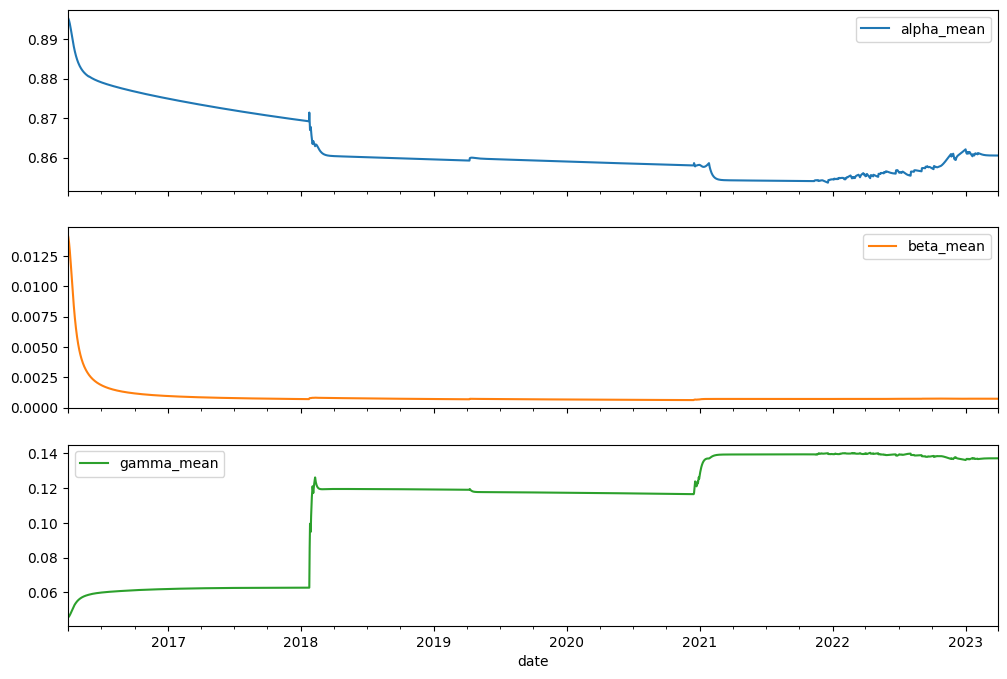

In [28]:
res_tokyo_15["filter_history"][["alpha_mean", "beta_mean", "gamma_mean"]].plot(
    subplots=True, figsize=(12, 8), sharex=True
)

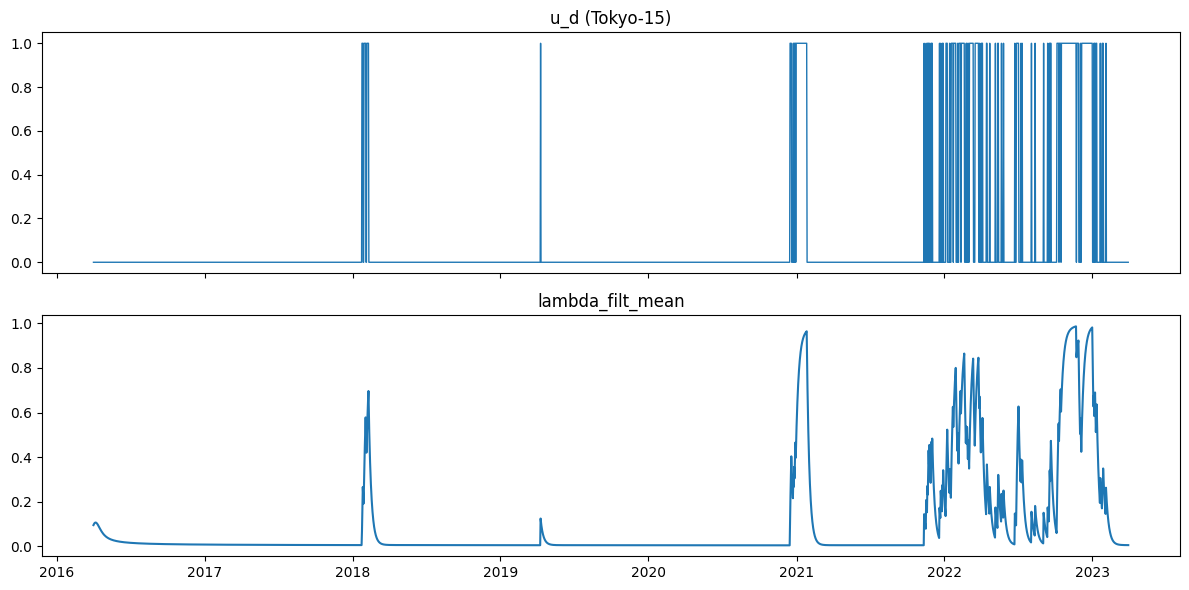

In [29]:
fig, axes = plt.subplots(2, 1, figsize=(12,6), sharex=True)

axes[0].plot(u_tokyo_15.index, u_tokyo_15.values, lw=1)
axes[0].set_title("u_d (Tokyo-15)")

axes[1].plot(res_tokyo_15["lambda_filt_mean"], lw=1.5)
axes[1].set_title("lambda_filt_mean")

plt.tight_layout()
plt.show()

## 事前分布の工夫
$0 \leq \alpha \leq 1$からロジット変換した値を正規分布に
$$
\text{logit}(\alpha) \sim \mathcal{N}(\mu_\alpha , \sigma^2_{\alpha})
$$

$0 \leq \beta , 0 \leq \gamma$から対数変換した値を正規分布に

$$
\log{\beta} \sim \mathcal{N}(\mu_\beta , \sigma^2_{\beta})\ , \ \log{\gamma} \sim \mathcal{N}(\mu_\gamma , \sigma^2_{\gamma})
$$

In [30]:
import numpy as np
import pandas as pd


# ==========================================
# 基本変換
# ==========================================
def logit(p, eps=1e-8):
    p = np.clip(p, eps, 1.0 - eps)
    return np.log(p / (1.0 - p))


def inv_logit(z):
    return 1.0 / (1.0 + np.exp(-z))


# ==========================================
# 自己相関（簡易版）
# ==========================================
def sample_autocorr(x, lag):
    x = np.asarray(x, dtype=float)
    if lag >= len(x):
        return np.nan

    x0 = x[:-lag]
    x1 = x[lag:]

    x0c = x0 - x0.mean()
    x1c = x1 - x1.mean()

    denom = np.sqrt(np.sum(x0c**2) * np.sum(x1c**2))
    if denom <= 0:
        return np.nan

    return float(np.sum(x0c * x1c) / denom)


# ==========================================
# 0/1系列から粗い初期値を作る
# ==========================================
def estimate_hawkes1_rough_moments(
    u_series,
    max_lag=5,
    alpha_clip=(0.80, 0.995),
    beta_clip=(1e-4, 0.20),
    gamma_clip=(1e-4, 0.30),
):
    """
    Hawkes I 用の粗いモーメント法風初期推定

    Parameters
    ----------
    u_series : pd.Series or array-like
        0/1 系列
    max_lag : int
        alpha 推定用に見る自己相関の最大ラグ
    alpha_clip, beta_clip, gamma_clip : tuple
        粗い推定値の安全クリップ範囲

    Returns
    -------
    dict
        alpha_hat, beta_hat, gamma_hat, p, p11, p10, acfs
    """
    u = np.asarray(pd.Series(u_series).astype(int), dtype=float)
    T = len(u)

    if T < 20:
        raise ValueError("系列が短すぎます。少なくとも20点程度は欲しいです。")

    # ----------------------
    # 1. 全体発生率
    # ----------------------
    p = float(u.mean())
    p = np.clip(p, 1e-4, 1.0 - 1e-4)

    # ----------------------
    # 2. 条件付き発生率
    # ----------------------
    u_prev = u[:-1]
    u_curr = u[1:]

    mask_11 = (u_prev == 1)
    mask_10 = (u_prev == 0)

    if mask_11.sum() > 0:
        p11 = float(u_curr[mask_11].mean())
    else:
        p11 = p

    if mask_10.sum() > 0:
        p10 = float(u_curr[mask_10].mean())
    else:
        p10 = p

    delta = max(p11 - p10, 1e-4)

    # ----------------------
    # 3. 自己相関の減衰から alpha を粗く推定
    # ----------------------
    acfs = []
    for lag in range(1, max_lag + 1):
        ac = sample_autocorr(u, lag)
        if np.isfinite(ac) and ac > 0:
            acfs.append((lag, ac))

    if len(acfs) >= 2:
        # log(acf_k) ≈ c + k log(alpha) を雑に当てる
        lags = np.array([k for k, ac in acfs], dtype=float)
        vals = np.array([ac for k, ac in acfs], dtype=float)

        y = np.log(np.clip(vals, 1e-8, None))
        x = lags

        A = np.vstack([np.ones_like(x), x]).T
        coef = np.linalg.lstsq(A, y, rcond=None)[0]
        slope = coef[1]

        alpha_hat = float(np.exp(slope))
    elif len(acfs) == 1:
        alpha_hat = float(acfs[0][1])
    else:
        alpha_hat = 0.92  # fallback

    alpha_hat = float(np.clip(alpha_hat, alpha_clip[0], alpha_clip[1]))

    # ----------------------
    # 4. gamma を直後効果から粗く推定
    # ----------------------
    # p11 - p10 をジャンプ幅の proxy とみなす
    gamma_hat = float(np.clip(delta, gamma_clip[0], gamma_clip[1]))

    # ----------------------
    # 5. beta を定常平均から逆算（粗い）
    #    p ≈ (beta + gamma*p) / (1 - alpha)
    #    -> beta ≈ p(1-alpha) - gamma*p
    # ----------------------
    beta_hat = p * (1.0 - alpha_hat) - gamma_hat * p
    beta_hat = float(np.clip(beta_hat, beta_clip[0], beta_clip[1]))

    return {
        "alpha_hat": alpha_hat,
        "beta_hat": beta_hat,
        "gamma_hat": gamma_hat,
        "p": p,
        "p11": p11,
        "p10": p10,
        "acfs": acfs,
    }


# ==========================================
# 変換後正規分布の事前パラメータを作る
# ==========================================
def build_transformed_normal_prior_params(
    u_series,
    max_lag=5,
    alpha_sd_logit=0.8,
    beta_sd_log=1.0,
    gamma_sd_log=1.0,
):
    """
    0/1系列から
      logit(alpha) ~ N(mu_alpha, sigma_alpha^2)
      log(beta)    ~ N(mu_beta,  sigma_beta^2)
      log(gamma)   ~ N(mu_gamma, sigma_gamma^2)
    の事前パラメータを作る

    Returns
    -------
    dict
    """
    rough = estimate_hawkes1_rough_moments(
        u_series=u_series,
        max_lag=max_lag,
    )

    alpha_hat = rough["alpha_hat"]
    beta_hat = rough["beta_hat"]
    gamma_hat = rough["gamma_hat"]

    prior_params = {
        "alpha_hat": alpha_hat,
        "beta_hat": beta_hat,
        "gamma_hat": gamma_hat,

        "mu_alpha_logit": logit(alpha_hat),
        "sd_alpha_logit": float(alpha_sd_logit),

        "mu_beta_log": float(np.log(beta_hat)),
        "sd_beta_log": float(beta_sd_log),

        "mu_gamma_log": float(np.log(gamma_hat)),
        "sd_gamma_log": float(gamma_sd_log),

        # 参考情報
        "p": rough["p"],
        "p11": rough["p11"],
        "p10": rough["p10"],
        "acfs": rough["acfs"],
    }

    return prior_params

In [31]:
import numpy as np
import pandas as pd


# ==========================================
# 基本変換
# ==========================================
def logit(p, eps=1e-8):
    p = np.clip(p, eps, 1.0 - eps)
    return np.log(p / (1.0 - p))


def inv_logit(z):
    return 1.0 / (1.0 + np.exp(-z))


# ==========================================
# 既存ユーティリティ
# ==========================================
def systematic_resample(weights, rng):
    n = len(weights)
    positions = (rng.random() + np.arange(n)) / n
    cumsum = np.cumsum(weights)
    indexes = np.zeros(n, dtype=int)

    i, j = 0, 0
    while i < n:
        if positions[i] < cumsum[j]:
            indexes[i] = j
            i += 1
        else:
            j += 1
    return indexes


def weighted_quantile(values, quantiles, sample_weight=None):
    values = np.asarray(values, dtype=float)
    quantiles = np.asarray(quantiles, dtype=float)

    if sample_weight is None:
        sample_weight = np.ones(len(values), dtype=float)
    else:
        sample_weight = np.asarray(sample_weight, dtype=float)

    sorter = np.argsort(values)
    values = values[sorter]
    sample_weight = sample_weight[sorter]

    cdf = np.cumsum(sample_weight)
    cdf = cdf / cdf[-1]

    return np.interp(quantiles, cdf, values)


def posterior_summary_from_particles(particles_df, weight_col="weight"):
    w = particles_df[weight_col].to_numpy(dtype=float)

    out = {}
    for col in ["alpha", "beta", "gamma"]:
        x = particles_df[col].to_numpy(dtype=float)
        mean = np.sum(w * x)
        q05, q50, q95 = weighted_quantile(x, [0.05, 0.50, 0.95], sample_weight=w)
        out[col] = {
            "mean": mean,
            "q05": q05,
            "median": q50,
            "q95": q95,
        }
    return pd.DataFrame(out).T


# ==========================================
# 自己相関（簡易版）
# ==========================================
def sample_autocorr(x, lag):
    x = np.asarray(x, dtype=float)
    if lag >= len(x):
        return np.nan

    x0 = x[:-lag]
    x1 = x[lag:]

    x0c = x0 - x0.mean()
    x1c = x1 - x1.mean()

    denom = np.sqrt(np.sum(x0c**2) * np.sum(x1c**2))
    if denom <= 0:
        return np.nan

    return float(np.sum(x0c * x1c) / denom)


# ==========================================
# 粗いモーメント法風推定
# ==========================================
def estimate_hawkes1_rough_moments(
    u_series,
    max_lag=5,
    alpha_clip=(0.80, 0.995),
    beta_clip=(1e-4, 0.20),
    gamma_clip=(1e-4, 0.30),
):
    u = np.asarray(pd.Series(u_series).astype(int), dtype=float)
    T = len(u)

    if T < 20:
        raise ValueError("系列が短すぎます。少なくとも20点程度は欲しいです。")

    # 全体発生率
    p = float(u.mean())
    p = np.clip(p, 1e-4, 1.0 - 1e-4)

    # 条件付き発生率
    u_prev = u[:-1]
    u_curr = u[1:]

    mask_11 = (u_prev == 1)
    mask_10 = (u_prev == 0)

    p11 = float(u_curr[mask_11].mean()) if mask_11.sum() > 0 else p
    p10 = float(u_curr[mask_10].mean()) if mask_10.sum() > 0 else p

    delta = max(p11 - p10, 1e-4)

    # 自己相関の減衰から alpha を推定
    acfs = []
    for lag in range(1, max_lag + 1):
        ac = sample_autocorr(u, lag)
        if np.isfinite(ac) and ac > 0:
            acfs.append((lag, ac))

    if len(acfs) >= 2:
        lags = np.array([k for k, ac in acfs], dtype=float)
        vals = np.array([ac for k, ac in acfs], dtype=float)

        y = np.log(np.clip(vals, 1e-8, None))
        x = lags

        A = np.vstack([np.ones_like(x), x]).T
        coef = np.linalg.lstsq(A, y, rcond=None)[0]
        slope = coef[1]

        alpha_hat = float(np.exp(slope))
    elif len(acfs) == 1:
        alpha_hat = float(acfs[0][1])
    else:
        alpha_hat = 0.92

    alpha_hat = float(np.clip(alpha_hat, alpha_clip[0], alpha_clip[1]))

    # gamma を直後効果から作る
    gamma_hat = float(np.clip(delta, gamma_clip[0], gamma_clip[1]))

    # beta を定常平均から粗く逆算
    # p ≈ (beta + gamma*p) / (1 - alpha)
    beta_hat = p * (1.0 - alpha_hat) - gamma_hat * p
    beta_hat = float(np.clip(beta_hat, beta_clip[0], beta_clip[1]))

    return {
        "alpha_hat": alpha_hat,
        "beta_hat": beta_hat,
        "gamma_hat": gamma_hat,
        "p": p,
        "p11": p11,
        "p10": p10,
        "acfs": acfs,
    }


# ==========================================
# 変換後正規事前のパラメータ作成
# ==========================================
def build_transformed_normal_prior_params(
    u_series,
    max_lag=5,
    alpha_sd_logit=0.8,
    beta_sd_log=1.0,
    gamma_sd_log=1.0,
):
    rough = estimate_hawkes1_rough_moments(
        u_series=u_series,
        max_lag=max_lag,
    )

    alpha_hat = rough["alpha_hat"]
    beta_hat = rough["beta_hat"]
    gamma_hat = rough["gamma_hat"]

    prior_info = {
        "rough_estimates": {
            "alpha_hat": alpha_hat,
            "beta_hat": beta_hat,
            "gamma_hat": gamma_hat,
        },
        "transformed_normal_priors": {
            "mu_alpha_logit": logit(alpha_hat),
            "sd_alpha_logit": float(alpha_sd_logit),
            "mu_beta_log": float(np.log(beta_hat)),
            "sd_beta_log": float(beta_sd_log),
            "mu_gamma_log": float(np.log(gamma_hat)),
            "sd_gamma_log": float(gamma_sd_log),
        },
        "diagnostics": {
            "p": rough["p"],
            "p11": rough["p11"],
            "p10": rough["p10"],
            "acfs": rough["acfs"],
        }
    }
    return prior_info


# ==========================================
# 変換後正規分布から粒子生成
# ==========================================
def sample_prior_particles_from_transformed_normal(
    n_particles,
    rng,
    prior_info,
    margin=1e-4,
    max_beta=0.5,
    max_gamma=0.5,
):
    pri = prior_info["transformed_normal_priors"]

    mu_alpha = float(pri["mu_alpha_logit"])
    sd_alpha = float(pri["sd_alpha_logit"])

    mu_beta = float(pri["mu_beta_log"])
    sd_beta = float(pri["sd_beta_log"])

    mu_gamma = float(pri["mu_gamma_log"])
    sd_gamma = float(pri["sd_gamma_log"])

    alpha_list = []
    beta_list = []
    gamma_list = []

    need = n_particles
    while len(alpha_list) < n_particles:
        m = max(need * 3, 1000)

        z_alpha = rng.normal(mu_alpha, sd_alpha, size=m)
        z_beta  = rng.normal(mu_beta,  sd_beta,  size=m)
        z_gamma = rng.normal(mu_gamma, sd_gamma, size=m)

        alpha = inv_logit(z_alpha)
        beta  = np.exp(z_beta)
        gamma = np.exp(z_gamma)

        # 暴走防止のため上限を軽く入れる
        beta = np.clip(beta, 1e-8, max_beta)
        gamma = np.clip(gamma, 1e-8, max_gamma)

        # 安定制約
        stationary_max = (beta + gamma) / (1.0 - alpha)
        mask = stationary_max <= (1.0 - margin)

        alpha_list.extend(alpha[mask].tolist())
        beta_list.extend(beta[mask].tolist())
        gamma_list.extend(gamma[mask].tolist())

        need = n_particles - len(alpha_list)

    alpha = np.array(alpha_list[:n_particles], dtype=float)
    beta = np.array(beta_list[:n_particles], dtype=float)
    gamma = np.array(gamma_list[:n_particles], dtype=float)

    return alpha, beta, gamma


# ==========================================
# 変換後正規事前を使う逐次ベイズ推定
# ==========================================
def fit_hawkes1_sequential_bayes_with_prior_info(
    u_series,
    prior_info,
    n_particles=20000,
    seed=42,
    ess_threshold_ratio=0.5,
    clip_eps=1e-6,
    lambda0_mode="empirical",
):
    """
    build_transformed_normal_prior_params(...) の結果を受け取って
    逐次ベイズ推定を行う版
    """
    rng = np.random.default_rng(seed)

    u_series = u_series.astype(int).copy()
    dates = pd.to_datetime(u_series.index)
    u = u_series.to_numpy(dtype=int)

    # ----------------------
    # 1. 初期粒子
    # ----------------------
    alpha, beta, gamma = sample_prior_particles_from_transformed_normal(
        n_particles=n_particles,
        rng=rng,
        prior_info=prior_info,
    )

    weights = np.full(n_particles, 1.0 / n_particles, dtype=float)

    # ----------------------
    # 2. 初期状態 lambda_0^+
    # ----------------------
    if lambda0_mode == "empirical":
        lambda0 = max(u.mean(), 0.001)
        lam_plus = np.full(n_particles, lambda0, dtype=float)
    elif lambda0_mode == "stationary":
        lam_plus = beta / (1.0 - alpha)
    else:
        raise ValueError("lambda0_mode must be 'empirical' or 'stationary'")

    lam_plus = np.clip(lam_plus, clip_eps, 1.0 - clip_eps)

    records = []
    lambda_pred_mean_list = []
    lambda_filt_mean_list = []

    # ----------------------
    # 3. 逐次更新
    # ----------------------
    for d in range(len(u)):
        # 予測
        lam_minus = alpha * lam_plus + beta
        lam_minus = np.clip(lam_minus, clip_eps, 1.0 - clip_eps)

        # 尤度
        if u[d] == 1:
            likelihood = lam_minus
        else:
            likelihood = 1.0 - lam_minus

        # 重み更新
        weights *= likelihood
        wsum = weights.sum()

        if not np.isfinite(wsum) or wsum <= 0:
            weights = np.full(n_particles, 1.0 / n_particles, dtype=float)
        else:
            weights /= wsum

        # 事後平均
        alpha_mean = np.sum(weights * alpha)
        beta_mean  = np.sum(weights * beta)
        gamma_mean = np.sum(weights * gamma)

        lambda_pred_mean = np.sum(weights * lam_minus)

        # 状態更新
        lam_plus = lam_minus + gamma * u[d]
        lam_plus = np.clip(lam_plus, clip_eps, 1.0 - clip_eps)

        lambda_filt_mean = np.sum(weights * lam_plus)

        # ESS
        ess = 1.0 / np.sum(weights ** 2)

        records.append({
            "date": dates[d],
            "u": u[d],
            "alpha_mean": alpha_mean,
            "beta_mean": beta_mean,
            "gamma_mean": gamma_mean,
            "lambda_pred_mean": lambda_pred_mean,
            "lambda_filt_mean": lambda_filt_mean,
            "ESS": ess,
        })

        lambda_pred_mean_list.append(lambda_pred_mean)
        lambda_filt_mean_list.append(lambda_filt_mean)

        # リサンプリング
        if ess < n_particles * ess_threshold_ratio:
            idx = systematic_resample(weights, rng)

            alpha = alpha[idx]
            beta = beta[idx]
            gamma = gamma[idx]
            lam_plus = lam_plus[idx]

            weights = np.full(n_particles, 1.0 / n_particles, dtype=float)

    # ----------------------
    # 4. 最終結果
    # ----------------------
    posterior_particles = pd.DataFrame({
        "alpha": alpha,
        "beta": beta,
        "gamma": gamma,
        "weight": weights,
    })

    posterior_summary = posterior_summary_from_particles(
        posterior_particles,
        weight_col="weight"
    )

    filter_history = pd.DataFrame(records).set_index("date")

    lambda_pred_mean = pd.Series(
        lambda_pred_mean_list,
        index=dates,
        name="lambda_pred_mean"
    )
    lambda_filt_mean = pd.Series(
        lambda_filt_mean_list,
        index=dates,
        name="lambda_filt_mean"
    )

    result = {
        "prior_info": prior_info,
        "posterior_particles": posterior_particles,
        "posterior_summary": posterior_summary,
        "filter_history": filter_history,
        "lambda_pred_mean": lambda_pred_mean,
        "lambda_filt_mean": lambda_filt_mean,
    }
    return result

In [32]:
#初期値
prior_tokyo_15 = build_transformed_normal_prior_params(
    u_tokyo_15,
    max_lag=5,
    alpha_sd_logit=0.8,
    beta_sd_log=1.0,
    gamma_sd_log=1.0,
)

prior_tokyo_15

{'rough_estimates': {'alpha_hat': 0.9494972354160123,
  'beta_hat': 0.0001,
  'gamma_hat': 0.3},
 'transformed_normal_priors': {'mu_alpha_logit': np.float64(2.933904539606978),
  'sd_alpha_logit': 0.8,
  'mu_beta_log': -9.210340371976182,
  'sd_beta_log': 1.0,
  'mu_gamma_log': -1.2039728043259361,
  'sd_gamma_log': 1.0},
 'diagnostics': {'p': np.float64(0.0903755868544601),
  'p11': 0.7229437229437229,
  'p10': 0.027538726333907058,
  'acfs': [(1, 0.6954049966098158),
   (2, 0.6430388380452953),
   (3, 0.6239862635211474),
   (4, 0.566853367801235),
   (5, 0.5715965069413345)]}}

In [33]:
re_res_tokyo_15 = fit_hawkes1_sequential_bayes_with_prior_info(
    u_tokyo_15,
    prior_info=prior_tokyo_15,
    n_particles=20000,
    seed=42,
    ess_threshold_ratio=0.5,
    lambda0_mode="empirical",
)

In [34]:
re_res_tokyo_15["posterior_summary"]

,mean,q05,median,q95
alpha,0.842681,0.819681,0.843640,0.869964
beta,0.000383,0.000125,0.000346,0.000875
gamma,0.155331,0.128511,0.155803,0.176786


In [35]:
res_tokyo_15["posterior_summary"]

,mean,q05,median,q95
alpha,0.860516,0.850165,0.863243,0.867367
beta,0.000734,0.000652,0.000693,0.000993
gamma,0.137016,0.131200,0.136054,0.144990


array([<Axes: xlabel='date'>, <Axes: xlabel='date'>,
       <Axes: xlabel='date'>], dtype=object)

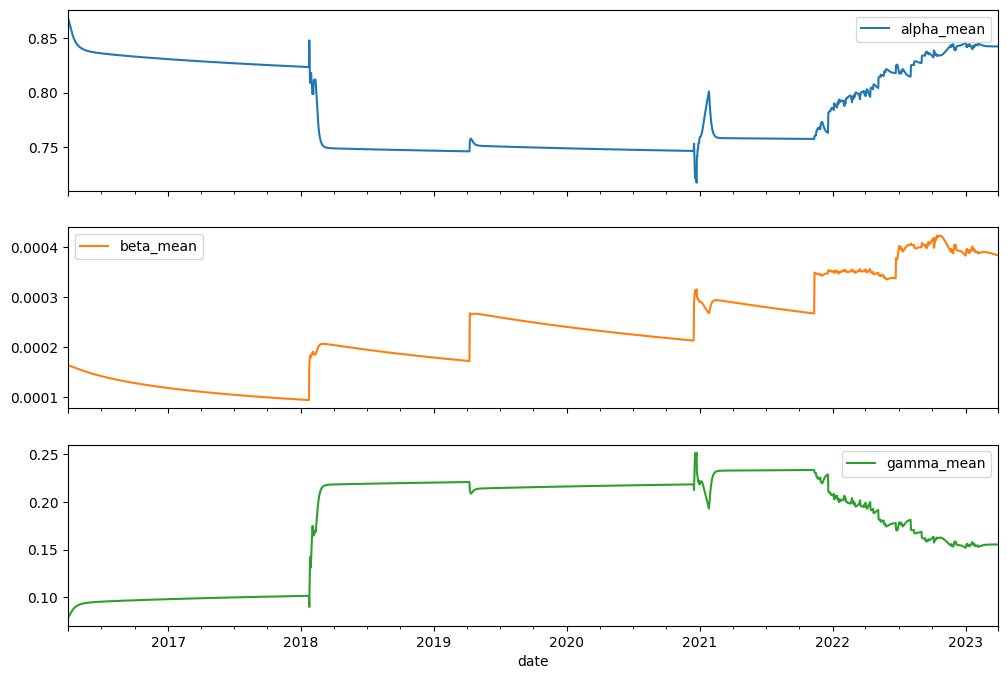

In [36]:
re_res_tokyo_15["filter_history"][["alpha_mean", "beta_mean", "gamma_mean"]].plot(
    subplots=True, figsize=(12, 8), sharex=True
)

array([<Axes: xlabel='date'>, <Axes: xlabel='date'>,
       <Axes: xlabel='date'>], dtype=object)

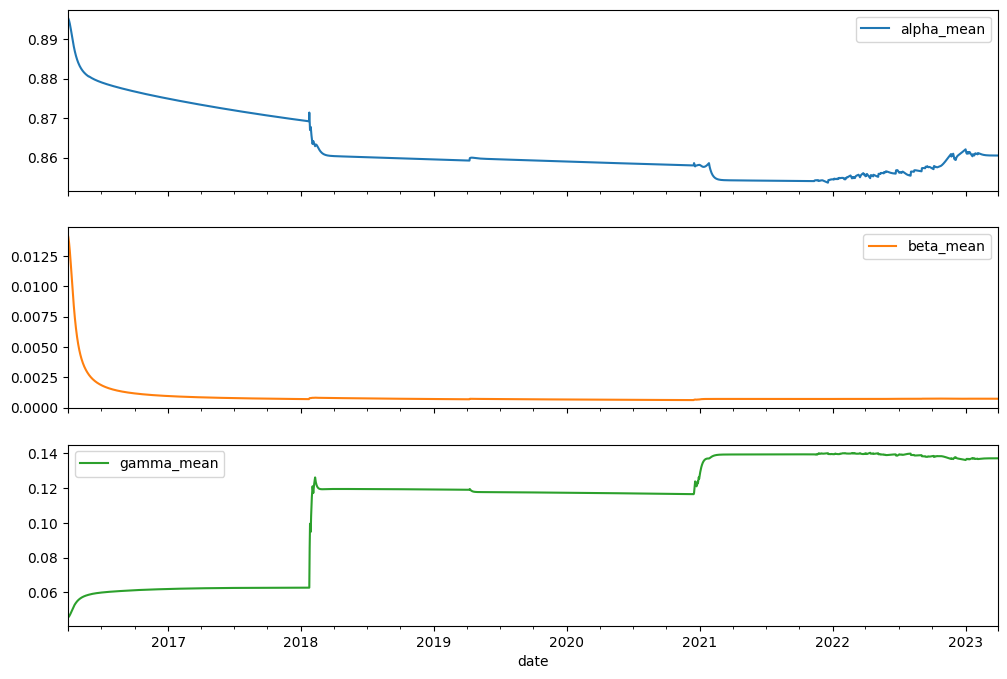

In [37]:
res_tokyo_15["filter_history"][["alpha_mean", "beta_mean", "gamma_mean"]].plot(
    subplots=True, figsize=(12, 8), sharex=True
)

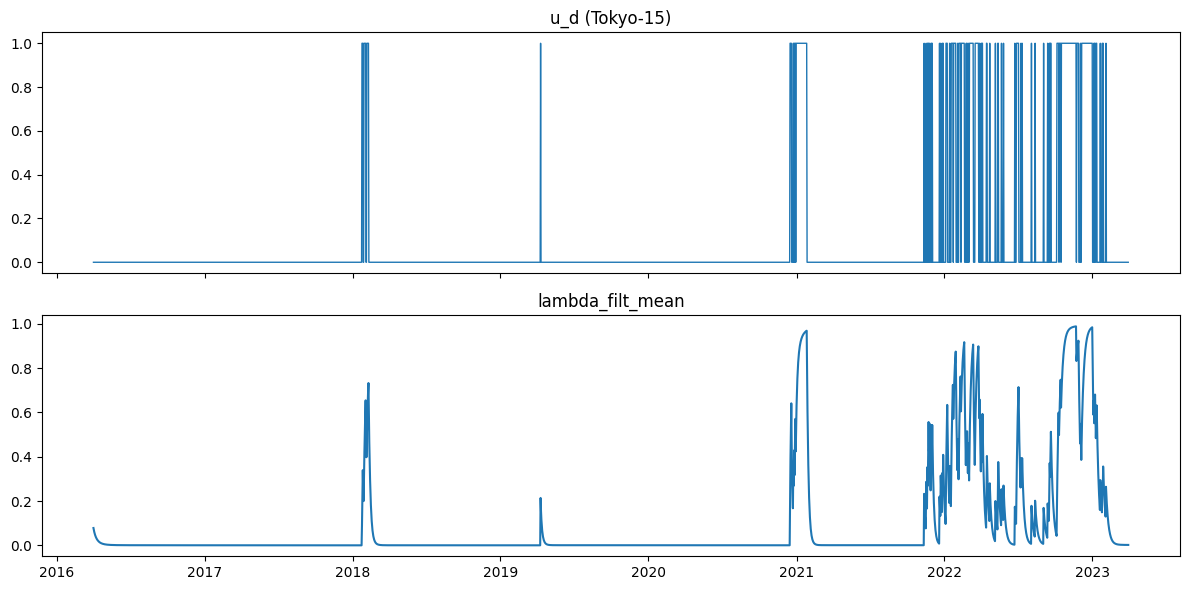

In [38]:
fig, axes = plt.subplots(2, 1, figsize=(12,6), sharex=True)

axes[0].plot(u_tokyo_15.index, u_tokyo_15.values, lw=1)
axes[0].set_title("u_d (Tokyo-15)")

axes[1].plot(re_res_tokyo_15["lambda_filt_mean"], lw=1.5)
axes[1].set_title("lambda_filt_mean")

plt.tight_layout()
plt.show()

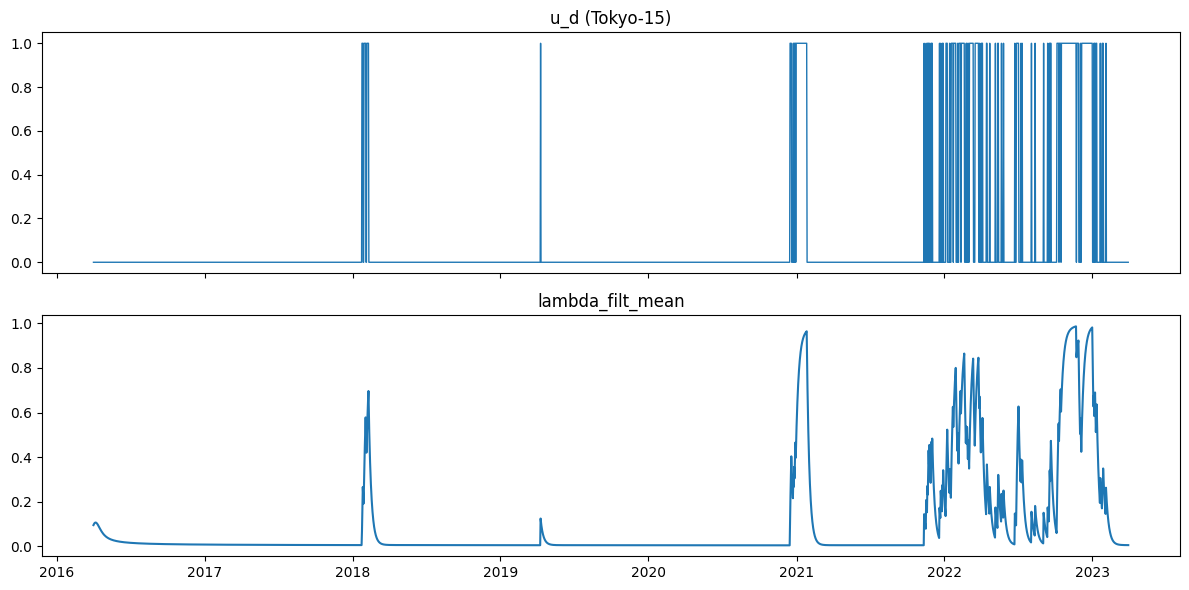

In [39]:
fig, axes = plt.subplots(2, 1, figsize=(12,6), sharex=True)

axes[0].plot(u_tokyo_15.index, u_tokyo_15.values, lw=1)
axes[0].set_title("u_d (Tokyo-15)")

axes[1].plot(res_tokyo_15["lambda_filt_mean"], lw=1.5)
axes[1].set_title("lambda_filt_mean")

plt.tight_layout()
plt.show()